In [1]:
# base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (log_loss, average_precision_score,
                             make_scorer, precision_score, roc_curve,
                             recall_score, precision_recall_curve,
                             roc_auc_score)

# Utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (cross_validate, cross_val_predict,
                                     StratifiedKFold, train_test_split, GridSearchCV)
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import optuna
import shap


import warnings
warnings.filterwarnings(
    'ignore',
    message='Found unknown categories.*',
    category=UserWarning
)

C:\Users\bekishev\Desktop\Credit Risk Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants
RANDOM_STATE = 42
PATH_TO_TRAIN_DATA = '../data/train-FIN_ANA_DATA.xls'
PATH_TO_TEST_DATA = '../data/test-FIN_ANA_DATA.xls'

In [3]:
df_train = pd.read_excel(PATH_TO_TRAIN_DATA)
df_test= pd.read_excel(PATH_TO_TEST_DATA)

In [4]:
# Target value encoding
mapping = {"G": 0, "B": 1}
df_train['QUALITY_OF_LOAN'] = df_train["QUALITY_OF_LOAN"].map(mapping)
df_test['QUALITY_OF_LOAN'] = df_test["QUALITY_OF_LOAN"].map(mapping)

In [5]:
X = df_train.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y = df_train['QUALITY_OF_LOAN']

X_test = df_test.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y_test = df_test['QUALITY_OF_LOAN']

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=RANDOM_STATE)
X_val, X_cal, y_val, y_cal = train_test_split(X_temp, y_temp, test_size=0.33,
                                              stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train DataFrame length is {X_train.shape[0]} ({X_train.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Validation DataFrame length is {X_val.shape[0]} ({X_val.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Calibration Dataframe length is {X_cal.shape[0]} ({X_cal.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Test DataFrame length is {X_test.shape[0]}")

Train DataFrame length is 26185 (70.0%)
Validation DataFrame length is 7519 (20.1%)
Calibration Dataframe length is 3704 (9.9%)
Test DataFrame length is 4310


In [7]:
categorial_features = ['INF_MARITAL_STATUS', 'INF_GENDER',
                       'COMPENSATION_CHARGED', 'CLIENT_TYPE',
                       'REPAY_MODE']
numeric_features = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
                    'INSTALL_SIZE', 'DUE_PAYMENT']

In [8]:
# LOGISTIC REGRESSION

# Numeric features preprocessing
numeric_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', RobustScaler())
])

# Categorial features preprocessing
categorial_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='infrequent_if_exist',
        min_frequency=0.01,
        sparse_output=False))
])

log_reg_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_logreg, numeric_features),
    ('categorical', categorial_pipeline_logreg, categorial_features)
])

# Logistic Regression Pipeline
log_reg_pipe = Pipeline(steps=[
    ('log_reg_transformer', log_reg_transformer),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

In [9]:
# XGBOOST

# Numeric features preprocessing
numeric_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1))
])

# Categorial features preprocessing
categorial_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


xgb_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_xgb, numeric_features),
    ('categorical', categorial_pipeline_xgb, categorial_features)
])

# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('xgb_transformer', xgb_transformer),
    ('model', XGBClassifier(
        random_state=RANDOM_STATE))
])

In [12]:
def evaluate_model_cv(model, X, y, n_folds = 5):
    """ Model evaluation function """
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        'precision' : make_scorer(precision_score, zero_division=0),
        'recall' : 'recall',
        'f1' : 'f1',
        'log_loss': 'neg_log_loss',
        'average_precision': 'average_precision',
        'roc_auc': 'roc_auc'
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=scoring,
        return_train_score=False
    )

    print(f"Results {model['model']}:")
    print(f"CV Precision: {cv_results['test_precision'].mean():.4f}")
    print(f"CV Recall: {cv_results['test_recall'].mean():.4f}")
    print(f"CV F1: {cv_results['test_f1'].mean():.4f}")
    print(f"CV LogLoss: {-cv_results['test_log_loss'].mean():.4f}")
    print(f"CV PR-AUC: {cv_results['test_average_precision'].mean():.4f}")
    print(f"CV ROC-AUC: {cv_results['test_roc_auc'].mean():.4f}")

    y_scores = cross_val_predict(model, X, y, cv=kfold,
                                     method='predict_proba')[:, 1]

    precision, recall, thresholds = precision_recall_curve(y, y_scores)
    avg_precision = cv_results['test_average_precision'].mean()

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f'PR-Curve (AUC = {avg_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

Results LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42):
CV Precision: 0.1375
CV Recall: 0.6207
CV F1: 0.2243
CV LogLoss: 0.6773
CV PR-AUC: 0.1485
CV ROC-AUC: 0.5909


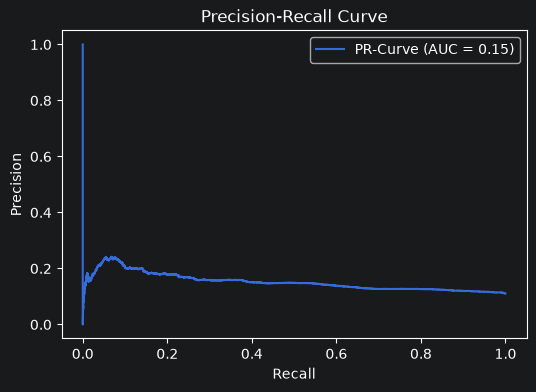

In [16]:
evaluate_model_cv(model=log_reg_pipe, X=X_train, y=y_train)

In [ ]:
evaluate_model_cv(model=xgb_pipeline, X=X_train, y=y_train)